# VAE Latent Market States on S&P 500 Data

This notebook extends the simple MNIST VAE intuition to **financial time-series windows**.

Instead of compressing a 28×28 image into a 2D latent vector, we compress a rolling market window into a 2D latent representation.

The goal is not direct price prediction. The goal is to ask whether the latent space learned by a VAE can represent market-state concepts such as:

- **Trend strength**
- **Volatility stress**
- **Mean-reversion pressure**
- **Macro commodity regime**

This notebook is intentionally simple and article-friendly. It can be used as a first Medium article prototype and later adapted as a component in the agri ETF / UCAIF research pipeline.

**Patch note:** v2 fixes a `KeyError: 'ticker'` caused by yfinance MultiIndex-layout differences and pandas groupby behaviour. The data loader now always returns a long dataframe with an explicit `ticker` column.


## 1. Setup

The notebook avoids `torchvision`, so it should not trigger the `torchvision::nms` issue.

Install dependencies if needed:

```bash
pip install yfinance torch scikit-learn pandas numpy matplotlib
```

In [1]:
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except Exception:
    YFINANCE_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)
print("yfinance available:", YFINANCE_AVAILABLE)

Using device: mps
yfinance available: True


## 2. Configuration

We use SPY as a tradable proxy for the S&P 500, then add macro/context assets.

Context tickers:

- `^VIX`: volatility stress proxy
- `DBC`: broad commodity proxy
- `UUP`: US dollar proxy
- `USO`: crude oil proxy
- `TLT`: long-duration bond proxy
- `GLD`: gold proxy

For your agri ETF paper, this exact structure can later be reused with `DBA`, `WEAT`, `CORN`, `SOYB`, and `CANE`.

In [2]:
@dataclass
class Config:
    market_ticker: str = "SPY"
    context_tickers: Tuple[str, ...] = ("^VIX", "DBC", "UUP", "USO", "TLT", "GLD")
    start_date: str = "2010-01-01"
    end_date: str | None = None
    window_size: int = 20
    horizon_days: int = 5
    latent_dim: int = 2
    batch_size: int = 128
    epochs: int = 40
    learning_rate: float = 1e-3
    beta_kl: float = 0.001
    train_fraction: float = 0.75
    use_synthetic_if_download_fails: bool = True

cfg = Config()
cfg

Config(market_ticker='SPY', context_tickers=('^VIX', 'DBC', 'UUP', 'USO', 'TLT', 'GLD'), start_date='2010-01-01', end_date=None, window_size=20, horizon_days=5, latent_dim=2, batch_size=128, epochs=40, learning_rate=0.001, beta_kl=0.001, train_fraction=0.75, use_synthetic_if_download_fails=True)

## 3. Data loading

The default mode downloads daily OHLCV data through `yfinance`.

If download fails, the notebook creates a synthetic market dataset so that the VAE pipeline still runs. Synthetic mode is only for debugging the mechanics.

In [3]:
def download_market_data(cfg: Config) -> pd.DataFrame:
    """Download OHLCV data and return a clean long dataframe.

    yfinance can return MultiIndex columns in two different layouts depending on
    version and parameters:
      1. first level = ticker, second level = OHLCV field
      2. first level = OHLCV field, second level = ticker

    This function handles both, and always returns columns:
      date, open, high, low, close, volume, ticker
    """
    if not YFINANCE_AVAILABLE:
        raise RuntimeError("yfinance is not available")

    tickers = [cfg.market_ticker] + list(cfg.context_tickers)
    raw = yf.download(
        tickers,
        start=cfg.start_date,
        end=cfg.end_date,
        auto_adjust=True,
        progress=False,
        group_by="ticker",
        threads=True,
    )

    if raw.empty:
        raise RuntimeError("No data downloaded")

    def clean_cols(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df.columns = [str(c).lower().replace(" ", "_") for c in df.columns]
        df = df.reset_index().rename(columns={"Date": "date", "Datetime": "date", "index": "date"})
        df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)
        return df

    frames = []

    if isinstance(raw.columns, pd.MultiIndex):
        level0 = set(raw.columns.get_level_values(0))
        level1 = set(raw.columns.get_level_values(1))

        for ticker in tickers:
            temp = None

            # Layout A: columns like ('SPY', 'Close')
            if ticker in level0:
                temp = raw[ticker].copy()

            # Layout B: columns like ('Close', 'SPY')
            elif ticker in level1:
                temp = raw.xs(ticker, axis=1, level=1).copy()

            if temp is None or temp.empty:
                print(f"Warning: no data found for {ticker}")
                continue

            temp = clean_cols(temp)
            temp["ticker"] = ticker
            frames.append(temp)

    else:
        # Single ticker fallback.
        temp = clean_cols(raw)
        temp["ticker"] = tickers[0]
        frames.append(temp)

    if not frames:
        raise RuntimeError("No ticker frames were created from yfinance output")

    out = pd.concat(frames, ignore_index=True)

    # Ensure the required fields exist. Some index-like series may not include volume.
    for col in ["open", "high", "low", "close"]:
        if col not in out.columns:
            raise ValueError(f"Required column missing after download: {col}. Columns: {out.columns.tolist()}")
    if "volume" not in out.columns:
        out["volume"] = np.nan

    keep = ["date", "open", "high", "low", "close", "volume", "ticker"]
    out = out[keep].dropna(subset=["date", "open", "high", "low", "close", "ticker"])
    out = out.sort_values(["ticker", "date"]).reset_index(drop=True)
    return out


def make_synthetic_market_data(cfg: Config, n_days: int = 2600) -> pd.DataFrame:
    """Synthetic fallback: creates regime-like OHLCV for SPY and context tickers."""
    tickers = [cfg.market_ticker] + list(cfg.context_tickers)
    dates = pd.bdate_range(cfg.start_date, periods=n_days)
    rng = np.random.default_rng(RANDOM_STATE)

    regimes = rng.choice([0, 1, 2, 3], size=n_days, p=[0.45, 0.25, 0.20, 0.10])

    rows = []
    for ticker in tickers:
        price = 100.0
        for i, d in enumerate(dates):
            r = regimes[i]
            base_mu = 0.0002
            vol = 0.008

            if ticker == cfg.market_ticker:
                if r == 1:
                    mu, vol = 0.0009, 0.010
                elif r == 2:
                    mu, vol = -0.0008, 0.022
                elif r == 3:
                    mu, vol = 0.0001, 0.014
                else:
                    mu, vol = base_mu, vol
            elif ticker == "^VIX":
                mu, vol = (0.002 if r == 2 else -0.0002), 0.030
            elif ticker == "DBC":
                mu, vol = (0.0012 if r == 3 else 0.0001), 0.012
            elif ticker == "UUP":
                mu, vol = (0.0008 if r == 2 else -0.0001), 0.006
            elif ticker == "USO":
                mu, vol = (0.0015 if r == 3 else 0.0001), 0.020
            elif ticker == "TLT":
                mu, vol = (0.0008 if r == 2 else -0.0001), 0.009
            elif ticker == "GLD":
                mu, vol = (0.0007 if r in [2, 3] else 0.0001), 0.010
            else:
                mu, vol = base_mu, vol

            ret = rng.normal(mu, vol)
            open_p = price * (1 + rng.normal(0, vol / 4))
            close_p = max(1.0, open_p * (1 + ret))
            hi = max(open_p, close_p) * (1 + abs(rng.normal(0, vol / 2)))
            lo = min(open_p, close_p) * (1 - abs(rng.normal(0, vol / 2)))
            volume = int(abs(rng.normal(2_000_000, 500_000)) * (1.5 if r == 2 else 1.0))
            price = close_p
            rows.append([d, open_p, hi, lo, close_p, volume, ticker])

    return pd.DataFrame(rows, columns=["date", "open", "high", "low", "close", "volume", "ticker"])


try:
    prices = download_market_data(cfg)
    print("Downloaded real data:", prices.shape)
except Exception as e:
    print("Download failed:", repr(e))
    if cfg.use_synthetic_if_download_fails:
        prices = make_synthetic_market_data(cfg)
        print("Using synthetic fallback:", prices.shape)
    else:
        raise

print("Columns:", prices.columns.tolist())
print("Tickers:", sorted(prices["ticker"].unique()))
prices.head()


Downloaded real data: (29114, 7)
Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'ticker']
Tickers: ['DBC', 'GLD', 'SPY', 'TLT', 'USO', 'UUP', '^VIX']


,date,open,high,low,close,volume,ticker
0,2010-01-04,21.279666,21.338846,21.195122,21.338846,2046900.0,DBC
1,2010-01-05,21.364210,21.414936,21.237395,21.364210,2335400.0,DBC
2,2010-01-06,21.474114,21.753108,21.389570,21.744654,2262600.0,DBC
3,2010-01-07,21.668564,21.685473,21.474113,21.474113,1604100.0,DBC
4,2010-01-08,21.423390,21.541751,21.330391,21.457207,1565300.0,DBC


## 4. Feature engineering

We build features that correspond to the four interpretive concepts.

### Trend strength
Examples: 20-day return, 60-day return, moving-average slope, distance from moving average.

### Volatility stress
Examples: realized volatility, range percentage, VIX level and VIX z-score.

### Mean-reversion pressure
Examples: Bollinger z-score, RSI, distance from recent mean.

### Macro commodity regime
Examples: broad commodity momentum, dollar strength, crude oil momentum.

In [4]:

def rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def add_single_ticker_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add single-ticker market-state features.

    Important: this function does not rely on pandas groupby.apply.
    The outer loop explicitly adds ticker back after feature generation.
    """
    df = df.sort_values("date").copy()
    c = df["close"]
    h = df["high"]
    l = df["low"]
    v = df["volume"]

    df["ret_1d"] = c.pct_change()
    df["ret_5d"] = c.pct_change(5)
    df["ret_20d"] = c.pct_change(20)
    df["ret_60d"] = c.pct_change(60)

    df["ma_20"] = c.rolling(20).mean()
    df["ma_60"] = c.rolling(60).mean()
    df["ma_gap_20"] = c / df["ma_20"] - 1
    df["ma_gap_60"] = c / df["ma_60"] - 1
    df["ma_slope_20"] = df["ma_20"].pct_change(5)

    df["realized_vol_20"] = df["ret_1d"].rolling(20).std() * np.sqrt(252)
    df["range_pct"] = (h - l) / c.shift(1)
    df["range_shock_20"] = df["range_pct"] / df["range_pct"].rolling(20).median()

    df["bollinger_z_20"] = (c - df["ma_20"]) / c.rolling(20).std()
    df["rsi_14"] = rsi(c, 14)
    df["volume_z_20"] = (v - v.rolling(20).mean()) / v.rolling(20).std()

    df["forward_ret_5d"] = c.shift(-5) / c - 1
    return df


required_price_cols = {"date", "ticker", "open", "high", "low", "close"}
missing_price_cols = required_price_cols - set(prices.columns)
if missing_price_cols:
    raise ValueError(f"prices is missing required columns: {missing_price_cols}. Available: {prices.columns.tolist()}")

# Make sure date and ticker are plain columns, not index levels.
prices = prices.copy().reset_index(drop=True)
prices["date"] = pd.to_datetime(prices["date"]).dt.tz_localize(None)
prices["ticker"] = prices["ticker"].astype(str)

# Avoid pandas groupby.apply behavior changes by building frames explicitly.
feature_frames = []
for ticker, g in prices.groupby("ticker", sort=False):
    temp = add_single_ticker_features(g.copy())
    temp["ticker"] = ticker  # preserve ticker explicitly
    feature_frames.append(temp.reset_index(drop=True))

feature_df = pd.concat(feature_frames, ignore_index=True)
feature_df = feature_df.sort_values(["ticker", "date"]).reset_index(drop=True)

print("Feature dataframe shape:", feature_df.shape)
print("Feature columns include ticker:", "ticker" in feature_df.columns)
print("Tickers:", sorted(feature_df["ticker"].unique()))
feature_df[["date", "ticker", "close", "ret_20d", "realized_vol_20", "bollinger_z_20"]].tail()


Feature dataframe shape: (29114, 23)
Feature columns include ticker: True
Tickers: ['DBC', 'GLD', 'SPY', 'TLT', 'USO', 'UUP', '^VIX']


,date,ticker,close,ret_20d,realized_vol_20,bollinger_z_20
29109,2026-07-13,^VIX,17.16,-0.117284,1.170289,0.078292
29110,2026-07-14,^VIX,16.50,-0.066742,1.133043,-0.417970
29111,2026-07-15,^VIX,15.67,-0.032716,1.106631,-1.060543
29112,2026-07-16,^VIX,16.73,0.019500,1.131490,-0.216023
29113,2026-07-17,^VIX,18.77,0.017896,1.129009,1.404759


In [5]:

def make_wide_context(feature_df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Convert long ticker-level features into one market-level dataframe.

    The VAE in this notebook models SPY market windows, while context tickers
    provide macro/commodity/dollar/oil information.
    """
    df = feature_df.copy()

    # Defensive repairs: date/ticker sometimes arrive as index levels after groupby operations.
    for needed in ["date", "ticker"]:
        if needed not in df.columns and needed in getattr(df.index, "names", []):
            df = df.reset_index()

    if "ticker" not in df.columns:
        raise KeyError(
            "feature_df has no 'ticker' column. The prices dataframe is fine, but the feature-building cell likely used old groupby.apply code. "
            "Restart the kernel and rerun the explicit feature_frames loop. "
            f"Available columns: {df.columns.tolist()}"
        )
    if "date" not in df.columns:
        raise KeyError(f"feature_df has no 'date' column. Available columns: {df.columns.tolist()}")

    df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)
    df["ticker"] = df["ticker"].astype(str)

    # pivot_table is safer than pivot if duplicate rows exist for the same date/ticker.
    wide_close = df.pivot_table(index="date", columns="ticker", values="close", aggfunc="last").sort_index()

    if cfg.market_ticker not in wide_close.columns:
        raise KeyError(
            f"Market ticker {cfg.market_ticker} not found in close matrix. "
            f"Available tickers: {wide_close.columns.tolist()}"
        )

    market = (
        df[df["ticker"] == cfg.market_ticker]
        .sort_values("date")
        .drop_duplicates(subset=["date"], keep="last")
        .set_index("date")
    )

    out = pd.DataFrame(index=wide_close.index)
    out["close"] = wide_close[cfg.market_ticker]
    out["forward_ret_5d"] = market["forward_ret_5d"]

    out["trend_ret_20"] = market["ret_20d"]
    out["trend_ret_60"] = market["ret_60d"]
    out["trend_ma_gap_20"] = market["ma_gap_20"]
    out["trend_ma_slope_20"] = market["ma_slope_20"]

    out["vol_realized_20"] = market["realized_vol_20"]
    out["vol_range_shock_20"] = market["range_shock_20"]
    out["vol_range_pct"] = market["range_pct"]

    out["mr_bollinger_z_20"] = market["bollinger_z_20"]
    out["mr_rsi_14"] = market["rsi_14"]
    out["mr_ma_gap_20"] = market["ma_gap_20"]

    for ticker in cfg.context_tickers:
        if ticker in wide_close.columns:
            clean_name = ticker.replace("^", "")
            out[f"ctx_{clean_name}_ret_5d"] = wide_close[ticker].pct_change(5)
            out[f"ctx_{clean_name}_ret_20d"] = wide_close[ticker].pct_change(20)

    if "^VIX" in wide_close.columns:
        vix = wide_close["^VIX"]
        out["vix_level"] = vix
        out["vix_z_60"] = (vix - vix.rolling(60).mean()) / vix.rolling(60).std()
    else:
        out["vix_level"] = np.nan
        out["vix_z_60"] = 0.0

    out["commodity_regime_20"] = wide_close["DBC"].pct_change(20) if "DBC" in wide_close.columns else 0.0
    out["dollar_regime_20"] = wide_close["UUP"].pct_change(20) if "UUP" in wide_close.columns else 0.0
    out["oil_regime_20"] = wide_close["USO"].pct_change(20) if "USO" in wide_close.columns else 0.0

    # Four article-friendly interpretable labels.
    out["trend_strength"] = out[["trend_ret_20", "trend_ma_gap_20", "trend_ma_slope_20"]].mean(axis=1)
    out["volatility_stress"] = out[["vol_realized_20", "vol_range_shock_20", "vix_z_60"]].mean(axis=1)
    out["mean_reversion_pressure"] = out[["mr_bollinger_z_20", "mr_ma_gap_20"]].mean(axis=1)
    out["macro_commodity_regime"] = out[["commodity_regime_20", "oil_regime_20"]].mean(axis=1) - out["dollar_regime_20"].fillna(0)

    return out.reset_index().rename(columns={"index": "date"}).dropna().sort_values("date")


market_state = make_wide_context(feature_df, cfg)
print(market_state.shape)
market_state.tail()


(4092, 34)


,date,close,forward_ret_5d,trend_ret_20,trend_ret_60,trend_ma_gap_20,trend_ma_slope_20,vol_realized_20,vol_range_shock_20,vol_range_pct,...,ctx_GLD_ret_20d,vix_level,vix_z_60,commodity_regime_20,dollar_regime_20,oil_regime_20,trend_strength,volatility_stress,mean_reversion_pressure,macro_commodity_regime
4150,2026-07-06,751.280029,-0.002809,-0.005118,0.114208,0.015340,-0.003139,0.183671,0.533374,0.006713,...,-0.070854,15.570000,-1.552421,-0.096386,0.017241,-0.236873,0.002361,-0.278459,0.750299,-0.183871
4151,2026-07-07,747.710022,0.005510,0.016387,0.102552,0.009693,-0.001417,0.158156,0.687484,0.007654,...,-0.047320,16.129999,-1.114443,-0.064317,0.013562,-0.181176,0.008221,-0.089601,0.467235,-0.136308
4152,2026-07-08,745.400024,0.012624,0.010958,0.099874,0.006025,-0.000210,0.158667,0.797687,0.008880,...,-0.057442,16.900000,-0.542177,-0.056668,0.011773,-0.169737,0.005591,0.138059,0.289312,-0.124976
4153,2026-07-09,751.710022,-0.001317,0.022518,0.098450,0.013409,0.001708,0.160455,0.879246,0.008559,...,-0.032243,15.840000,-1.258501,-0.051256,0.012496,-0.169764,0.012545,-0.072933,0.626370,-0.123005
4154,2026-07-10,754.950012,-0.015445,0.043374,0.089904,0.015628,0.004338,0.147680,1.005975,0.009738,...,0.006487,15.030000,-1.750579,-0.056565,0.012121,-0.190618,0.021113,-0.198975,0.801646,-0.135713


## 5. Build rolling windows for VAE

For images, VAE input was a flattened image.

For finance, VAE input is a flattened rolling market window:

```text
window_size × number_of_features
```

Example:

```text
20 trading days × 20 features = 400 input values
```

In [6]:
INTERPRETATION_COLS = [
    "trend_strength",
    "volatility_stress",
    "mean_reversion_pressure",
    "macro_commodity_regime",
]

EXCLUDE_COLS = ["date", "close", "forward_ret_5d"]
FEATURE_COLS = [c for c in market_state.columns if c not in EXCLUDE_COLS]

print("Number of features:", len(FEATURE_COLS))
print(FEATURE_COLS)

Number of features: 31
['trend_ret_20', 'trend_ret_60', 'trend_ma_gap_20', 'trend_ma_slope_20', 'vol_realized_20', 'vol_range_shock_20', 'vol_range_pct', 'mr_bollinger_z_20', 'mr_rsi_14', 'mr_ma_gap_20', 'ctx_VIX_ret_5d', 'ctx_VIX_ret_20d', 'ctx_DBC_ret_5d', 'ctx_DBC_ret_20d', 'ctx_UUP_ret_5d', 'ctx_UUP_ret_20d', 'ctx_USO_ret_5d', 'ctx_USO_ret_20d', 'ctx_TLT_ret_5d', 'ctx_TLT_ret_20d', 'ctx_GLD_ret_5d', 'ctx_GLD_ret_20d', 'vix_level', 'vix_z_60', 'commodity_regime_20', 'dollar_regime_20', 'oil_regime_20', 'trend_strength', 'volatility_stress', 'mean_reversion_pressure', 'macro_commodity_regime']


In [7]:
def make_vae_windows(df: pd.DataFrame, feature_cols: List[str], window_size: int):
    df = df.sort_values("date").reset_index(drop=True).copy()
    X = df[feature_cols].values.astype("float32")
    dates = []
    windows = []
    rows = []

    for end_idx in range(window_size - 1, len(df)):
        start_idx = end_idx - window_size + 1
        window = X[start_idx:end_idx + 1]
        windows.append(window.reshape(-1))
        dates.append(df.loc[end_idx, "date"])
        rows.append(df.loc[end_idx].copy())

    window_df = pd.DataFrame(rows).reset_index(drop=True)
    window_df["window_end_date"] = dates
    return np.array(windows, dtype="float32"), window_df


X_raw, window_meta = make_vae_windows(market_state, FEATURE_COLS, cfg.window_size)
print("Raw window matrix:", X_raw.shape)
window_meta[["date", "trend_strength", "volatility_stress", "mean_reversion_pressure", "macro_commodity_regime"]].tail()

Raw window matrix: (4073, 620)


,date,trend_strength,volatility_stress,mean_reversion_pressure,macro_commodity_regime
4068,2026-07-06,0.002361,-0.278459,0.750299,-0.183871
4069,2026-07-07,0.008221,-0.089601,0.467235,-0.136308
4070,2026-07-08,0.005591,0.138059,0.289312,-0.124976
4071,2026-07-09,0.012545,-0.072933,0.626370,-0.123005
4072,2026-07-10,0.021113,-0.198975,0.801646,-0.135713


In [8]:
n = len(X_raw)
train_n = int(n * cfg.train_fraction)

X_train_raw = X_raw[:train_n]
X_test_raw = X_raw[train_n:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype("float32")
X_test = scaler.transform(X_test_raw).astype("float32")
X_all = scaler.transform(X_raw).astype("float32")

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train)),
    batch_size=cfg.batch_size,
    shuffle=True,
)

test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test)),
    batch_size=cfg.batch_size,
    shuffle=False,
)

input_dim = X_train.shape[1]
print("Input dimension:", input_dim)
print("Train windows:", len(X_train), "Test windows:", len(X_test))

Input dimension: 620
Train windows: 3054 Test windows: 1019


## 6. PyTorch VAE for finance windows

Important difference from MNIST:

- MNIST pixels are in `[0, 1]`, so binary cross-entropy works.
- Finance features are standardized continuous variables, so we use **mean squared reconstruction loss**.

In [9]:
class FinanceVAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128, latent_dim: int = 2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z)
        return reconstructed, mu, logvar


def vae_loss(reconstructed, x, mu, logvar, beta_kl: float = 0.001):
    recon = F.mse_loss(reconstructed, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta_kl * kl, recon, kl


model = FinanceVAE(input_dim=input_dim, hidden_dim=128, latent_dim=cfg.latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)
model

FinanceVAE(
  (encoder): Sequential(
    (0): Linear(in_features=620, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=620, bias=True)
  )
)

In [10]:
def train_vae(model, train_loader, epochs: int, beta_kl: float):
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = total_recon = total_kl = 0.0
        n_obs = 0

        for (x,) in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            reconstructed, mu, logvar = model(x)
            loss, recon, kl = vae_loss(reconstructed, x, mu, logvar, beta_kl=beta_kl)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()
            n_obs += x.shape[0]

        history.append({
            "epoch": epoch,
            "loss": total_loss / n_obs,
            "reconstruction": total_recon / n_obs,
            "kl": total_kl / n_obs,
        })
        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"Loss {total_loss / n_obs:.4f} | "
                f"Recon {total_recon / n_obs:.4f} | "
                f"KL {total_kl / n_obs:.4f}"
            )
    return pd.DataFrame(history)


history = train_vae(model, train_loader, cfg.epochs, cfg.beta_kl)

Epoch 001 | Loss 558.9239 | Recon 558.9124 | KL 11.4521
Epoch 005 | Loss 390.3742 | Recon 390.3469 | KL 27.2811
Epoch 010 | Loss 353.6799 | Recon 353.6432 | KL 36.6582
Epoch 015 | Loss 337.7707 | Recon 337.7278 | KL 42.8180
Epoch 020 | Loss 328.1387 | Recon 328.0911 | KL 47.6221
Epoch 025 | Loss 320.1853 | Recon 320.1324 | KL 52.8175
Epoch 030 | Loss 314.2885 | Recon 314.2317 | KL 56.7656
Epoch 035 | Loss 307.2319 | Recon 307.1723 | KL 59.5513
Epoch 040 | Loss 303.3396 | Recon 303.2782 | KL 61.4508


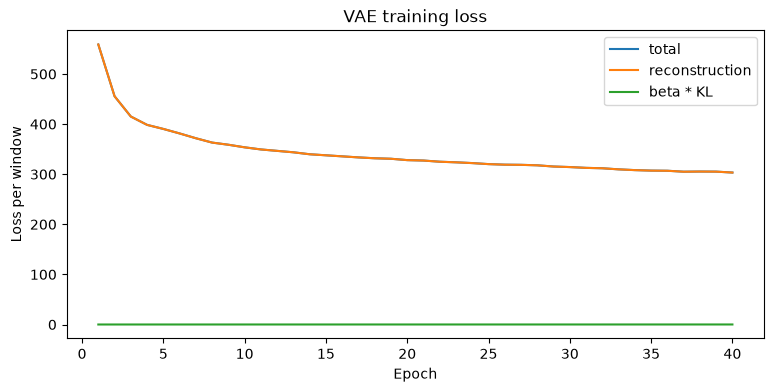

In [11]:
plt.figure(figsize=(9, 4))
plt.plot(history["epoch"], history["loss"], label="total")
plt.plot(history["epoch"], history["reconstruction"], label="reconstruction")
plt.plot(history["epoch"], history["kl"] * cfg.beta_kl, label="beta * KL")
plt.title("VAE training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss per window")
plt.legend()
plt.show()

## 7. Encode market windows into latent space

Each rolling market window becomes a point in 2D latent space.

If the VAE learns useful structure, this space may organize windows by trend, volatility stress, mean-reversion pressure, or macro commodity conditions.

In [24]:
def encode_windows(model, X: np.ndarray) -> pd.DataFrame:
    model.eval()
    x = torch.tensor(X, dtype=torch.float32).to(device)
    all_mu = []
    all_logvar = []
    all_recon = []

    with torch.no_grad():
        for i in range(0, len(x), 1024):
            batch = x[i:i+1024]
            mu, logvar = model.encode(batch)
            recon = model.decode(mu)
            all_mu.append(mu.cpu())
            all_logvar.append(logvar.cpu())
            all_recon.append(recon.cpu())

    mu = torch.cat(all_mu).numpy()
    logvar = torch.cat(all_logvar).numpy()
    recon = torch.cat(all_recon).numpy()
    recon_error = np.mean((X - recon) ** 2, axis=1)

    out = pd.DataFrame(mu, columns=[f"z{i+1}" for i in range(mu.shape[1])])
    for i in range(logvar.shape[1]):
        out[f"z{i+1}_uncertainty"] = np.exp(logvar[:, i])
    out["reconstruction_error"] = recon_error
    return out


latent = encode_windows(model, X_all)
analysis_df = pd.concat([window_meta.reset_index(drop=True), latent], axis=1)
analysis_df[["date", "z1", "z2", "reconstruction_error"] + INTERPRETATION_COLS].tail()

,date,z1,z2,reconstruction_error,trend_strength,volatility_stress,mean_reversion_pressure,macro_commodity_regime
4068,2026-07-06,-1.829795,3.709271,0.826331,0.002361,-0.278459,0.750299,-0.183871
4069,2026-07-07,-2.381891,3.773077,0.784276,0.008221,-0.089601,0.467235,-0.136308
4070,2026-07-08,-2.443593,3.619483,0.731865,0.005591,0.138059,0.289312,-0.124976
4071,2026-07-09,-2.675900,4.635183,0.674514,0.012545,-0.072933,0.626370,-0.123005
4072,2026-07-10,-2.957063,4.559062,0.625413,0.021113,-0.198975,0.801646,-0.135713


## 8. Interpreting the latent dimensions

A VAE does not name latent dimensions for us. We interpret them by asking:

- Is `z1` correlated with trend strength?
- Is `z2` correlated with volatility stress?
- Do high reconstruction-error windows correspond to unusual market periods?
- Do clusters in latent space have different forward-return profiles?

In [13]:
CORR_COLS = ["z1", "z2", "reconstruction_error"] + INTERPRETATION_COLS + ["forward_ret_5d"]
correlation_table = analysis_df[CORR_COLS].corr().loc[["z1", "z2", "reconstruction_error"], INTERPRETATION_COLS + ["forward_ret_5d"]]
correlation_table.round(3)

,trend_strength,volatility_stress,mean_reversion_pressure,macro_commodity_regime,forward_ret_5d
z1,0.180,-0.109,0.048,0.469,-0.095
z2,0.656,-0.419,0.386,0.128,-0.051
reconstruction_error,-0.246,0.184,-0.195,-0.121,0.105


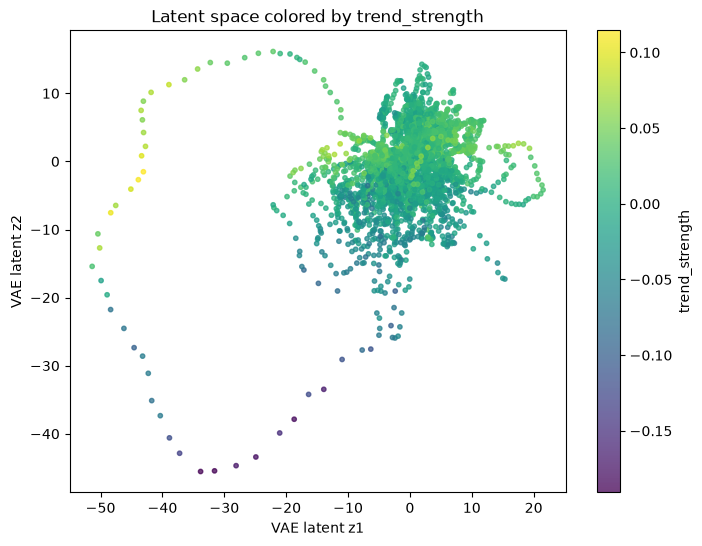

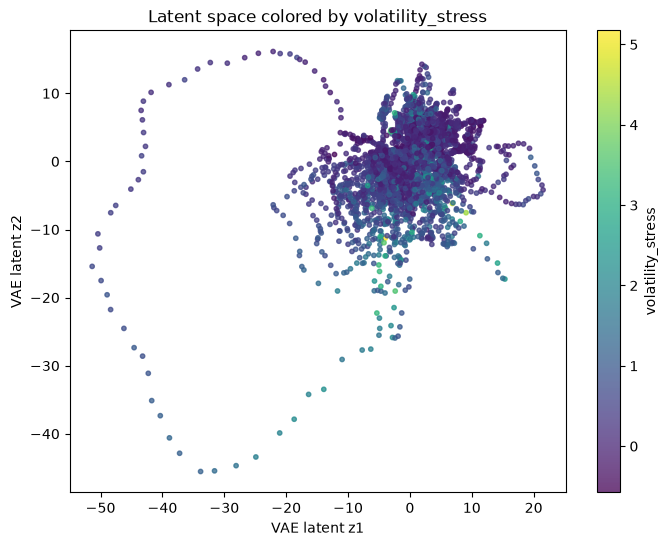

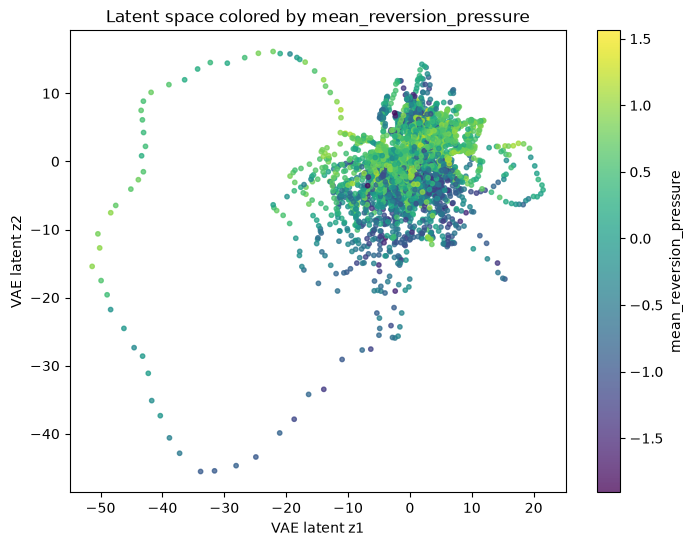

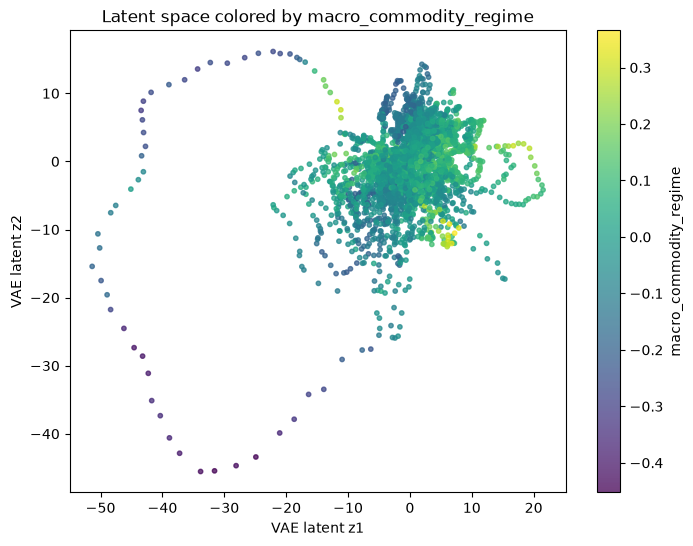

In [14]:
def scatter_latent(color_col: str, title: str | None = None):
    plt.figure(figsize=(8, 6))
    s = plt.scatter(
        analysis_df["z1"],
        analysis_df["z2"],
        c=analysis_df[color_col],
        cmap="viridis",
        s=10,
        alpha=0.75,
    )
    plt.colorbar(s, label=color_col)
    plt.xlabel("VAE latent z1")
    plt.ylabel("VAE latent z2")
    plt.title(title or f"Latent space colored by {color_col}")
    plt.show()


for col in INTERPRETATION_COLS:
    scatter_latent(col)

## 9. Latent regimes with simple clustering

To make the latent space more article-friendly, cluster the 2D points.

This lets us describe regimes like:

- high trend / low volatility
- high volatility stress
- mean-reversion pressure
- commodity-led macro regime

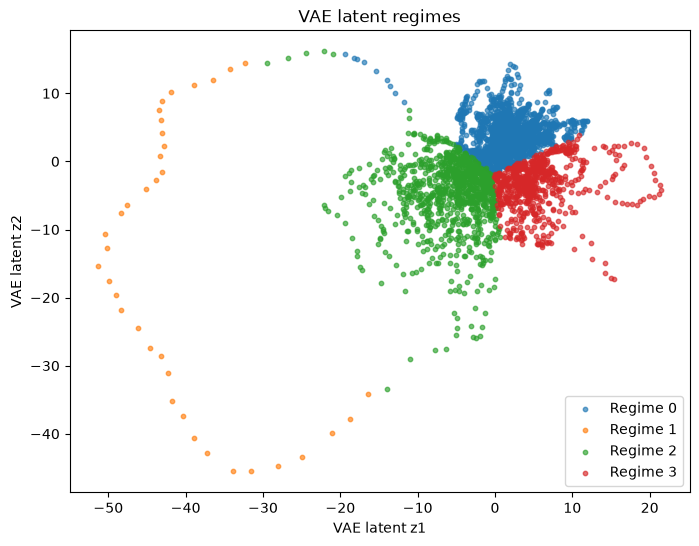

In [15]:
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=20)
analysis_df["latent_regime"] = kmeans.fit_predict(analysis_df[["z1", "z2"]])

plt.figure(figsize=(8, 6))
for regime, sub in analysis_df.groupby("latent_regime"):
    plt.scatter(sub["z1"], sub["z2"], s=10, alpha=0.65, label=f"Regime {regime}")
plt.xlabel("VAE latent z1")
plt.ylabel("VAE latent z2")
plt.title("VAE latent regimes")
plt.legend()
plt.show()

In [16]:
regime_summary = (
    analysis_df
    .groupby("latent_regime")
    .agg(
        n_windows=("date", "count"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        avg_trend_strength=("trend_strength", "mean"),
        avg_volatility_stress=("volatility_stress", "mean"),
        avg_mean_reversion_pressure=("mean_reversion_pressure", "mean"),
        avg_macro_commodity_regime=("macro_commodity_regime", "mean"),
        avg_forward_ret_5d=("forward_ret_5d", "mean"),
        avg_reconstruction_error=("reconstruction_error", "mean"),
    )
    .sort_values("n_windows", ascending=False)
)

regime_summary.round(4)

,n_windows,start_date,end_date,avg_trend_strength,avg_volatility_stress,avg_mean_reversion_pressure,avg_macro_commodity_regime,avg_forward_ret_5d,avg_reconstruction_error
latent_regime,,,,,,,,,
0,2218,2010-04-28,2026-07-10,0.0149,0.2566,0.4252,0.0004,0.0018,0.4161
2,1095,2010-05-11,2025-12-17,-0.0048,0.5655,0.0544,-0.0269,0.0046,0.7123
3,723,2010-05-04,2026-04-17,-0.0019,0.6416,-0.1504,0.0526,0.0026,0.6156
1,37,2020-03-13,2020-05-05,-0.0158,0.8091,0.1161,-0.2759,0.0230,1.4212


In [17]:
def name_regime(row):
    labels = []
    if row["avg_volatility_stress"] == regime_summary["avg_volatility_stress"].max():
        labels.append("volatility-stress")
    if row["avg_trend_strength"] == regime_summary["avg_trend_strength"].max():
        labels.append("trend-strength")
    if abs(row["avg_mean_reversion_pressure"]) == regime_summary["avg_mean_reversion_pressure"].abs().max():
        labels.append("mean-reversion-pressure")
    if row["avg_macro_commodity_regime"] == regime_summary["avg_macro_commodity_regime"].max():
        labels.append("commodity-macro")
    return ", ".join(labels) if labels else "mixed / neutral"

article_regimes = regime_summary.copy()
article_regimes["plain_english_label"] = article_regimes.apply(name_regime, axis=1)
article_regimes[["plain_english_label", "n_windows", "avg_forward_ret_5d", "avg_reconstruction_error"]].round(4)

,plain_english_label,n_windows,avg_forward_ret_5d,avg_reconstruction_error
latent_regime,,,,
0,"trend-strength, mean-reversion-pressure",2218,0.0018,0.4161
2,mixed / neutral,1095,0.0046,0.7123
3,commodity-macro,723,0.0026,0.6156
1,volatility-stress,37,0.0230,1.4212


## 10. Reconstruction error as an anomaly signal

A high reconstruction error means:

> This market window was difficult for the VAE to reconstruct from its learned latent representation.

In finance, that can be interpreted cautiously as an unusual or less-familiar state.

For a trading or decision-support framework, high reconstruction error can support an `ABSTAIN` decision.

In [18]:
top_anomalies = (
    analysis_df
    .sort_values("reconstruction_error", ascending=False)
    [["date", "reconstruction_error", "trend_strength", "volatility_stress", "mean_reversion_pressure", "macro_commodity_regime", "forward_ret_5d"]]
    .head(15)
)

top_anomalies.round(4)

,date,reconstruction_error,trend_strength,volatility_stress,mean_reversion_pressure,macro_commodity_regime,forward_ret_5d
4009,2026-04-07,2.7084,-0.0099,0.7530,0.1163,0.1923,0.0535
4011,2026-04-09,2.6693,0.0132,0.2123,0.9902,0.1004,0.0320
4010,2026-04-08,2.6075,0.0081,0.2771,0.8702,0.1029,0.0354
4003,2026-03-27,2.5657,-0.0443,1.2755,-1.1508,0.3094,0.0392
4007,2026-04-02,2.5573,-0.0173,0.8132,-0.0928,0.2552,0.0360
4012,2026-04-10,2.5538,0.0185,0.0280,0.8695,0.0296,0.0452
4006,2026-04-01,2.5392,-0.0207,0.5707,-0.1549,0.2146,0.0377
4002,2026-03-26,2.5186,-0.0358,1.0690,-0.9251,0.2831,0.0166
4013,2026-04-13,2.4926,0.0274,0.2601,0.9723,0.0584,0.0330
4004,2026-03-30,2.4545,-0.0460,1.2656,-1.0548,0.2876,0.0431


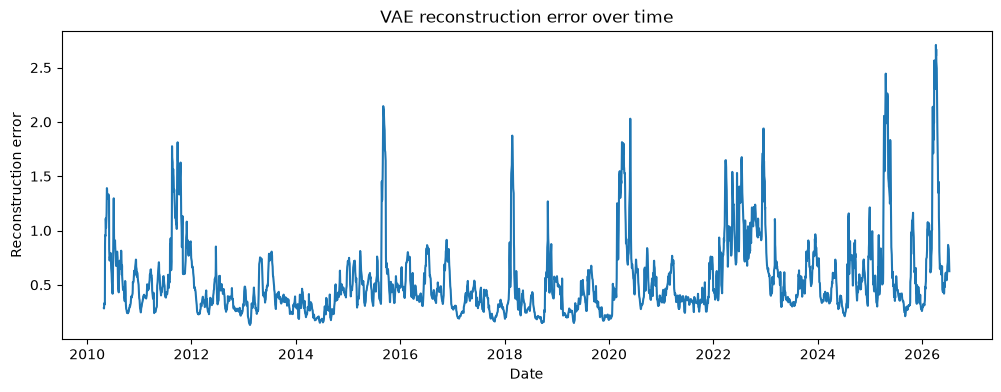

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(analysis_df["date"], analysis_df["reconstruction_error"])
plt.title("VAE reconstruction error over time")
plt.xlabel("Date")
plt.ylabel("Reconstruction error")
plt.show()

## 11. Simple action interpretation

This is not a complete trading model. It is a simple bridge to your adaptive market-state framework.

We can assign a rough interpretation:

- High trend strength + low volatility stress → trend-following conditions
- High mean-reversion pressure + moderate volatility → possible mean-reversion conditions
- High volatility stress or high reconstruction error → uncertainty / abstention conditions
- High commodity regime score → commodity-led macro context

In [20]:
def simple_state_label(row):
    vol_q = analysis_df["volatility_stress"].quantile(0.75)
    recon_q = analysis_df["reconstruction_error"].quantile(0.90)
    trend_q = analysis_df["trend_strength"].quantile(0.75)
    mr_q = analysis_df["mean_reversion_pressure"].abs().quantile(0.75)
    commodity_q = analysis_df["macro_commodity_regime"].quantile(0.75)

    if row["reconstruction_error"] >= recon_q or row["volatility_stress"] >= vol_q:
        return "ABSTAIN / STRESS"
    if abs(row["mean_reversion_pressure"]) >= mr_q:
        return "MEAN_REVERSION_PRESSURE"
    if row["trend_strength"] >= trend_q:
        return "TREND_STRENGTH"
    if row["macro_commodity_regime"] >= commodity_q:
        return "COMMODITY_MACRO"
    return "MIXED / NEUTRAL"

analysis_df["simple_state_label"] = analysis_df.apply(simple_state_label, axis=1)

state_summary = (
    analysis_df
    .groupby("simple_state_label")
    .agg(
        n_windows=("date", "count"),
        avg_forward_ret_5d=("forward_ret_5d", "mean"),
        avg_trend_strength=("trend_strength", "mean"),
        avg_volatility_stress=("volatility_stress", "mean"),
        avg_mean_reversion_pressure=("mean_reversion_pressure", "mean"),
        avg_macro_commodity_regime=("macro_commodity_regime", "mean"),
        avg_reconstruction_error=("reconstruction_error", "mean"),
    )
    .sort_values("n_windows", ascending=False)
)

state_summary.round(4)

,n_windows,avg_forward_ret_5d,avg_trend_strength,avg_volatility_stress,avg_mean_reversion_pressure,avg_macro_commodity_regime,avg_reconstruction_error
simple_state_label,,,,,,,
MIXED / NEUTRAL,1319,0.0026,0.0055,0.2284,0.2770,-0.0260,0.4400
ABSTAIN / STRESS,1252,0.0039,-0.0100,1.0032,-0.3368,-0.0192,0.7773
MEAN_REVERSION_PRESSURE,616,0.0022,0.0198,0.0500,0.8411,0.0210,0.4057
TREND_STRENGTH,558,0.0038,0.0295,0.0336,0.6151,0.0306,0.4702
COMMODITY_MACRO,328,-0.0001,0.0073,0.2297,0.2841,0.0840,0.4106


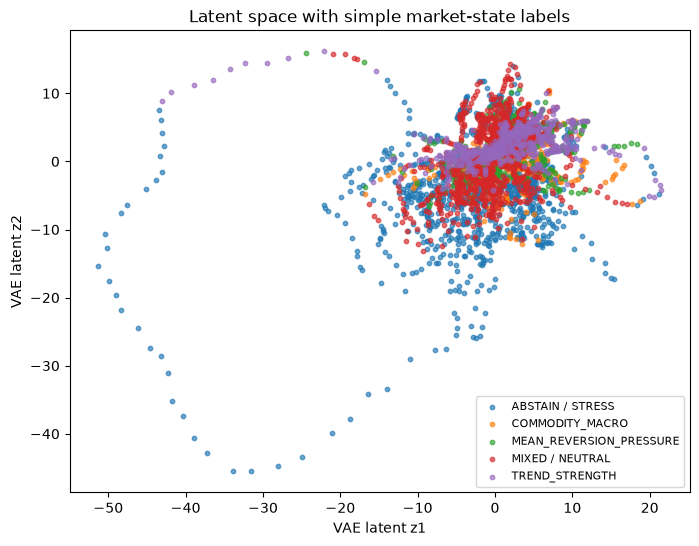

In [21]:
plt.figure(figsize=(8, 6))
for label, sub in analysis_df.groupby("simple_state_label"):
    plt.scatter(sub["z1"], sub["z2"], s=10, alpha=0.65, label=label)
plt.xlabel("VAE latent z1")
plt.ylabel("VAE latent z2")
plt.title("Latent space with simple market-state labels")
plt.legend(fontsize=8)
plt.show()

## 12. Article-friendly summary generator

This creates a first-pass written interpretation that can be edited into a Medium article.

In [23]:
def make_article_summary(corr_table: pd.DataFrame, regime_summary: pd.DataFrame, state_summary: pd.DataFrame) -> str:
    strongest = []
    for z in ["z1", "z2"]:
        vals = corr_table.loc[z].dropna().abs().sort_values(ascending=False)
        if len(vals):
            strongest.append((z, vals.index[0], corr_table.loc[z, vals.index[0]]))

    lines = []
    lines.append("# Draft interpretation")
    lines.append("")
    lines.append("The VAE compresses rolling S&P 500 market windows into a two-dimensional latent space.")
    lines.append("Instead of treating the latent variables as direct forecasts, we interpret them as market-state coordinates.")
    lines.append("")

    for z, concept, corr in strongest:
        lines.append(f"- `{z}` is most associated with `{concept}` in this run, with correlation {corr:.3f}.")

    lines.append("")
    lines.append("The latent clusters show whether the model separates trend, stress, mean-reversion pressure, and commodity/macro context.")
    lines.append("High reconstruction-error windows can be treated as unusual regimes where an adaptive system may prefer to abstain rather than force a trend or mean-reversion decision.")
    lines.append("")
    lines.append("For a UCAIF-style paper, the key message is not that the VAE predicts returns by itself. The contribution is that a probabilistic latent representation can become an input to an adaptive decision framework that chooses between trend-following, momentum, mean-reversion, or abstention.")

    return "".join(lines)


print(make_article_summary(correlation_table, regime_summary, state_summary))

# Draft interpretationThe VAE compresses rolling S&P 500 market windows into a two-dimensional latent space.Instead of treating the latent variables as direct forecasts, we interpret them as market-state coordinates.- `z1` is most associated with `macro_commodity_regime` in this run, with correlation 0.469.- `z2` is most associated with `trend_strength` in this run, with correlation 0.656.The latent clusters show whether the model separates trend, stress, mean-reversion pressure, and commodity/macro context.High reconstruction-error windows can be treated as unusual regimes where an adaptive system may prefer to abstain rather than force a trend or mean-reversion decision.For a UCAIF-style paper, the key message is not that the VAE predicts returns by itself. The contribution is that a probabilistic latent representation can become an input to an adaptive decision framework that chooses between trend-following, momentum, mean-reversion, or abstention.


## 13. How this connects to the agri ETF / UCAIF paper

This S&P 500 notebook is the intuition bridge.

For the agri ETF paper, replace the market universe with:

```python
TRADE_TICKERS = ("DBA", "WEAT", "CORN", "SOYB", "CANE")
CONTEXT_TICKERS = ("DBC", "UUP", "USO")
```

Then reuse the same conceptual pipeline:

```text
Rolling market window
    ↓
Trend / momentum / mean-reversion / volatility / macro features
    ↓
VAE latent representation
    ↓
Latent regime interpretation
    ↓
Adaptive action framework:
        FOLLOW_TREND
        FOLLOW_MOMENTUM
        MEAN_REVERT
        ABSTAIN
```

For publication, keep the claim modest:

> The VAE is not a standalone alpha model. It is a representation-learning tool for identifying market states and uncertainty.